In [1]:
import pandas as pd

# 1. Load data
df = pd.read_excel("stats_for_knn_shifted.xlsx")

# 2. Quick look
print(df.shape)
df.head()


(4863, 7)


,Player,Season,Pos,Age,Min,Injured,Injured_next_season
0,Aaron Hughes,2002-03,DF,22,3.139,1,1
1,Aaron Hughes,2003-04,DF,23,2.965,1,1
2,Aaron Hughes,2004-05,DF,24,1.676,1,1
3,Aaron Hughes,2005-06,DF,25,3.020,1,1
4,Aaron Hughes,2006-07,DF,26,1.291,1,0


In [5]:
df.info()
df.isna().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4863 entries, 0 to 4862
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player               4863 non-null   object 
 1   Season               4863 non-null   object 
 2   Pos                  4863 non-null   object 
 3   Age                  4863 non-null   int64  
 4   Min                  4863 non-null   float64
 5   Injured              4863 non-null   int64  
 6   Injured_next_season  4863 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 266.1+ KB


Player                 0
Season                 0
Pos                    0
Age                    0
Min                    0
Injured                0
Injured_next_season    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Keep only what we need
df_knn = df[["Age", "Injured"]].copy()

# Drop missing
df_knn = df_knn.dropna(subset=["Age", "Injured"])

df_knn.describe()


,Age,Injured
count,4863.000000,4863.000000
mean,25.322640,0.412708
std,4.242466,0.492372
min,15.000000,0.000000
25%,22.000000,0.000000
50%,25.000000,0.000000
75%,28.000000,1.000000
max,41.000000,1.000000


In [8]:
injury_counts = df_knn["Injured"].value_counts().sort_index()
injury_rate = df_knn["Injured"].mean()
print("Counts:\n", injury_counts)
print("Injury rate:", injury_rate)


Counts:
 Injured
0    2856
1    2007
Name: count, dtype: int64
Injury rate: 0.41270820481184456


In [9]:
X = df_knn[["Age"]]   # DataFrame with 1 column
y = df_knn["Injured"] # Series


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # keeps injury proportion similar in train and test
)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
from sklearn.neighbors import KNeighborsClassifier

k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
y_pred = knn.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("K =",k)
print("Accuracy:", acc)
print("Confusion matrix:\n", cm)
print("Report:\n", report)


K = 5
Accuracy: 0.5346127484578478
Confusion matrix:
 [[500 357]
 [322 280]]
Report:
               precision    recall  f1-score   support

           0       0.61      0.58      0.60       857
           1       0.44      0.47      0.45       602

    accuracy                           0.53      1459
   macro avg       0.52      0.52      0.52      1459
weighted avg       0.54      0.53      0.54      1459



In [38]:
cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm,
    index=["Actual: Not Injured (0)", "Actual: Injured (1)"],
    columns=["Predicted: Not Injured (0)", "Predicted: Injured (1)"]
)

print("Confusion Matrix:")
display(cm_table)

Confusion Matrix:


,Predicted: Not Injured (0),Predicted: Injured (1)
Actual: Not Injured (0),500,357
Actual: Injured (1),322,280


In [39]:
import numpy as np
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred_k))

best_k = k_values[int(np.argmax(scores))]
best_score = max(scores)

print("Best k:", best_k)
print("Best accuracy:", best_score)


Best k: 22
Best accuracy: 0.5873886223440713


In [40]:
# Train and evaluate model with the best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

# Confusion matrix for best k
cm_best = confusion_matrix(y_test, y_pred_best)
cm_best_table = pd.DataFrame(
    cm_best,
    index=["Actual: Not Injured (0)", "Actual: Injured (1)"],
    columns=["Predicted: Not Injured (0)", "Predicted: Injured (1)"]
)

print("\nConfusion Matrix for best k:")
display(cm_best_table)


Confusion Matrix for best k:


,Predicted: Not Injured (0),Predicted: Injured (1)
Actual: Not Injured (0),857,0
Actual: Injured (1),602,0


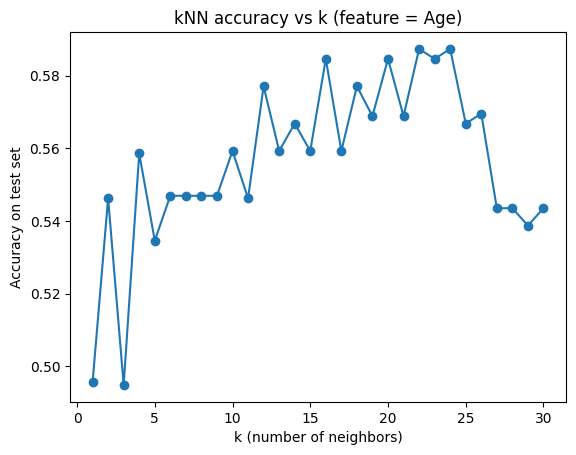

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, scores, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy on test set")
plt.title("kNN accuracy vs k (feature = Age)")
plt.show()


In [24]:
age_injury = (
    df_knn
    .groupby("Age")["Injured"]
    .mean()
    .reset_index()
    .rename(columns={"Injured": "injury_rate"})
    .sort_values("Age")
)
age_injury.head()


,Age,injury_rate
0,15,0.000000
1,16,0.117647
2,17,0.253521
3,18,0.303448
4,19,0.376812


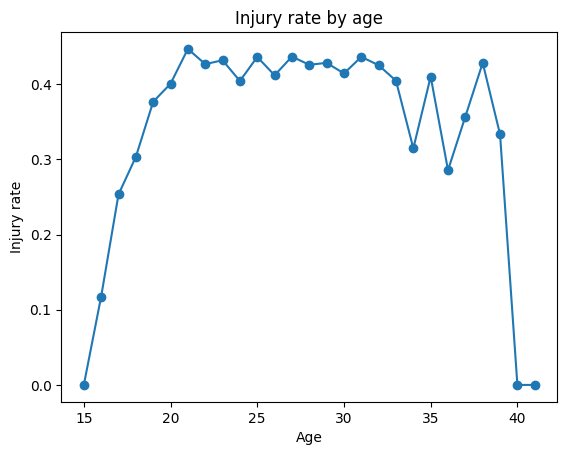

In [25]:
plt.figure()
plt.plot(age_injury["Age"], age_injury["injury_rate"], marker="o")
plt.xlabel("Age")
plt.ylabel("Injury rate")
plt.title("Injury rate by age")
plt.show()
